## 1. Setup and file loading

Load PyROOT in batch mode (no GUI windows, warnings-only logging), then
import the analysis toolkit modules (`analyze_root.py`, `analyze_proton_events.py`)
and point `FILE_PATH` at the NanoAOD file to analyze.

In [116]:
import os
import sys

import ROOT

ROOT.gROOT.SetBatch(True)
ROOT.gErrorIgnoreLevel = ROOT.kWarning

print("ROOT loaded successfully")
print(f"ROOT version: {ROOT.gROOT.GetVersion()}")

# Path to the NanoAOD file to analyze. Change this to point at your own file.
FILE_PATH = "examples/test.root"

assert os.path.exists(FILE_PATH), f"File not found: {FILE_PATH}"
print(f"Using input file: {FILE_PATH}")


ROOT loaded successfully
ROOT version: 6.40.04
Using input file: examples/test.root


## 2. Quick file structure overview

`analyze_root_file()` prints the tree(s), branches, and basic stats found in
the ROOT file, giving a quick sanity check of what's available before running
any RDataFrame analysis.

In [117]:
# Import the analysis toolkit modules
from analyze_root import analyze_root_file
from analyze_proton_events import PPSHistogramType, create_histograms_and_plots, plot_diamond_efficiency_maps

from IPython.display import Image, display


In [118]:
analyze_root_file(FILE_PATH)


=== NanoAOD Analysis: examples/test.root ===

Objects in ROOT file:

TFile**		examples/test.root	
 TFile*		examples/test.root	
  KEY: TObjString	tag;1	Collectable string class
  KEY: TTree	Events;1	Events
  KEY: TTree	LuminosityBlocks;1	LuminosityBlocks
  KEY: TTree	Runs;1	Runs
  KEY: TTree	MetaData;1	Job metadata
  KEY: TTree	ParameterSets;1	Parameter sets
Found trees: ['Events', 'LuminosityBlocks', 'Runs', 'MetaData', 'ParameterSets']

Tree 'Events': 346825 events
Tree 'LuminosityBlocks': 71 events
Tree 'Runs': 1 events
Tree 'MetaData': 1 events
Tree 'ParameterSets': 14239 events

Total events in all trees: 361137

--------------------------------------------------------------------------------

=== PPS & Proton Variables Analysis (regex: *PPS* OR *proton*) ===
Found PPS & Proton variables (25):

   1. HLT_DiPFJetAve180_PPSMatch_Xi0p3_QuadJet_Max2ProtPerRP
   2. HLT_PPSMaxTracksPerArm1
   3. HLT_PPSMaxTracksPerRP4
   4. HLT_PPSRandom
   5. PPSLocalTrack_decRPId
   6. PPSLocalTrack_mu

In [119]:
def rdata_analysis(file_path, filter_funcs=None):
    """
    RDataFrame analysis of PPS data - filtering, statistics, parallel processing

    Args:
        file_path: Path to ROOT file
        filter_funcs: List of filter functions to apply (optional)
                     Each function should take df and return filtered df
    """
    print("=== RDataFrame PPS Analysis ===")
    print(f"Analyzing file: {file_path}")
    print()

    df = ROOT.RDataFrame("Events", file_path)

    print(f"Total events in file: {df.Count().GetValue()}")

    # Filter events with at least one PPS track - a Must Have
    df_with_pps = df.Filter("nPPSLocalTrack > 0")
    events_with_pps = df_with_pps.Count().GetValue()

    print(f"Events with PPS data: {events_with_pps}")
    print()

    # Apply custom filters if provided
    if filter_funcs:
        print("=== Applying Custom Filters ===")
        df_filtered = df_with_pps

        for i, filter_func in enumerate(filter_funcs):
            print(f"Applying filter {i + 1}: {filter_func.__name__}")
            df_filtered = filter_func(df_filtered)
            count = df_filtered.Count().GetValue()
            print(f"  Events after filter: {count}")

        print()
        print("=== Filter Results ===")
        print(f"Events after all filters: {df_filtered.Count().GetValue()}")
        print()
    else:
        # No filters applied - use all PPS events
        df_filtered = df_with_pps

    return df_filtered


In [120]:
# Build the RDataFrame with no custom filters. This reports total events and
# events-with-PPS-data counts.

df_baseline = rdata_analysis(FILE_PATH)


=== RDataFrame PPS Analysis ===
Analyzing file: examples/test.root

Total events in file: 346825
Events with PPS data: 311565



## 3. RDataFrame filtering

`rdata_analysis()` builds an `RDataFrame` over the `Events` tree, reports the
total event count and how many events carry PPS data (`nPPSLocalTrack > 0`),
and optionally applies a list of custom filter functions in sequence
(logical AND). The cells below define and exercise several ready-made
filters: single-arm, double-arm, detector-specific, detector-type, and
xi-range selections.

In [121]:
# Implementations of the filter functions. Each takes an
# RDataFrame and returns a new, filtered RDataFrame.
def filter_double_arm_events(df):
    """
    Select events with tracks in both arms:
    - Left arm: RP ID 23 or 123
    - Right arm: RP ID 3 or 103
    """
    df_filtered = df.Filter(
        "(ROOT::VecOps::Any(PPSLocalTrack_decRPId == 23 || PPSLocalTrack_decRPId == 123)) && "
        "(ROOT::VecOps::Any(PPSLocalTrack_decRPId == 3 || PPSLocalTrack_decRPId == 103))",
        "Events with tracks in both arms (23|123) and (3|103)"
    )
    return df_filtered


def filter_single_arm_events(df):
    """
    Select events with tracks in only one arm (left OR right, but not both)
    """
    df_filtered = df.Filter(
        "(ROOT::VecOps::Any(PPSLocalTrack_decRPId == 23 || PPSLocalTrack_decRPId == 123)) != "
        "(ROOT::VecOps::Any(PPSLocalTrack_decRPId == 3 || PPSLocalTrack_decRPId == 103))",
        "Events with tracks in only one arm"
    )
    return df_filtered


def filter_detector_specific_events(df, rp_id):
    """
    Select events with tracks in specific Roman Pot detector
    """
    filter_expr = f"ROOT::VecOps::Any(PPSLocalTrack_decRPId == {rp_id})"
    df_filtered = df.Filter(filter_expr, f"Events with tracks in RP {rp_id}")
    return df_filtered


def filter_xi_ranged_events(df, xi_min, xi_max):
    """
    Select events with proton fractional momentum loss in specified range,
    using Proton_singleRP_xi.
    """
    xi_column = "Proton_singleRP_xi"

    filter_expr = f"ROOT::VecOps::Any({xi_column} >= {xi_min} && {xi_column} <= {xi_max})"
    df_filtered = df.Filter(filter_expr, f"Events with xi in [{xi_min}, {xi_max}] (using {xi_column})")
    return df_filtered


def filter_detector_type(df, detector_type):
    """
    Select events with tracks in specific detector type using PPSLocalTrack_rpType

    Args:
        df: RDataFrame
        detector_type: 'pixel' for silicon pixel detectors (rpType = 4)
                      'diamond' for diamond timing detectors (rpType = 5)

    Returns:
        Filtered RDataFrame
    """
    detector_type_map = {
        'pixel': 4,
        'diamond': 5
    }

    if detector_type.lower() not in detector_type_map:
        raise ValueError(f"Unknown detector type '{detector_type}'. Use 'pixel' or 'diamond'.")

    rp_type = detector_type_map[detector_type.lower()]
    filter_expr = f"ROOT::VecOps::Any(PPSLocalTrack_rpType == {rp_type})"

    df_filtered = df.Filter(filter_expr, f"Events with {detector_type} detector tracks (rpType={rp_type})")
    return df_filtered


In [122]:
# Single arm: tracks in only one arm (left OR right, not both)
df_single_arm = filter_single_arm_events(df_baseline)
print("Single-arm events:", df_single_arm.Count().GetValue())

Single-arm events: 34828


In [123]:
# Double arm: tracks in both arms simultaneously
df_double_arm = filter_double_arm_events(df_baseline)
print("Double-arm events:", df_double_arm.Count().GetValue())


Double-arm events: 276737


In [124]:
# Detector-specific: only events with a track in a given Roman Pot (e.g. RP 23)
df_rp22 = filter_detector_specific_events(df_baseline, rp_id=22)
print("Events with RP 22 tracks:", df_rp22.Count().GetValue())


Events with RP 22 tracks: 59946


In [125]:
# Detector type: pixel (rpType=4) vs diamond timing (rpType=5) detectors
df_pixel = filter_detector_type(df_baseline, "pixel")
print("Events with pixel-detector tracks:", df_pixel.Count().GetValue())

df_diamond = filter_detector_type(df_baseline, "diamond")
print("Events with diamond-detector tracks:", df_diamond.Count().GetValue())


Events with pixel-detector tracks: 311565
Events with diamond-detector tracks: 75275


In [126]:
# Xi range: proton fractional momentum loss in [xi_min, xi_max]

df_xi_range = filter_xi_ranged_events(df_baseline, xi_min=0.05, xi_max=0.06)
print("Events with xi in [0.05, 0.06]:", df_xi_range.Count().GetValue())


Events with xi in [0.05, 0.06]: 117834


### Combining multiple filters

`rdata_analysis()` accepts a **list** of filter functions, applied in
sequence (logical AND). Filters requiring extra arguments (like
`filter_detector_specific_events` or `filter_xi_ranged_events`) can be
wrapped in a `lambda`:

```python
filters = [
    filter_double_arm_events,
    lambda df: filter_detector_type(df, "pixel"),
    lambda df: filter_xi_ranged_events(df, 0.05, 0.2),
]
df_filtered = rdata_analysis(FILE_PATH, filters)
```


In [144]:
filters = [
    filter_double_arm_events,
    lambda df: filter_detector_type(df, "diamond"),
    lambda df: filter_xi_ranged_events(df, 0.05, 0.1),
]
df_filtered = rdata_analysis(FILE_PATH, filters)


=== RDataFrame PPS Analysis ===
Analyzing file: examples/test.root

Total events in file: 346825
Events with PPS data: 311565

=== Applying Custom Filters ===
Applying filter 1: filter_double_arm_events
  Events after filter: 276737
Applying filter 2: <lambda>
  Events after filter: 75275
Applying filter 3: <lambda>
  Events after filter: 68474

=== Filter Results ===
Events after all filters: 68474



## 4. Histogram generation

All 25 PPS/proton variables are exposed as members of the `PPSHistogramType`
enum. `create_histograms_and_plots()` books a `Histo1D` (or `Histo2D`, for
X-vs-Y track positions) for each requested type, saves them to a ROOT file
under `data/`, and renders each one as a PNG plot.

### Variable groups

- **Track variables**: `N_PPS_LOCAL_TRACK`, `PPS_LOCAL_TRACK_X`, `PPS_LOCAL_TRACK_Y`,
  `PPS_LOCAL_TRACK_DEC_RP_ID`, `PPS_LOCAL_TRACK_RP_TYPE`, `PPS_LOCAL_TRACK_TIME`,
  `PPS_LOCAL_TRACK_TIME_UNC`, `PPS_LOCAL_TRACK_MULTI_RP_PROTON_IDX`,
  `PPS_LOCAL_TRACK_SINGLE_RP_PROTON_IDX`
- **Multi-RP proton variables**: `N_PROTON_MULTI_RP`, `PROTON_MULTI_RP_ARM`,
  `PROTON_MULTI_RP_T`, `PROTON_MULTI_RP_THETA_X`, `PROTON_MULTI_RP_THETA_Y`,
  `PROTON_MULTI_RP_TIME`, `PROTON_MULTI_RP_TIME_UNC`, `PROTON_MULTI_RP_XI`
- **Single-RP proton variables**: `N_PROTON_SINGLE_RP`,
  `PROTON_SINGLE_RP_DEC_RP_ID`, `PROTON_SINGLE_RP_THETA_Y`, `PROTON_SINGLE_RP_XI`
- **HLT triggers**: `HLT_PPSMaxTracksPerArm1`, `HLT_PPSMaxTracksPerRP4`,
  `HLT_PPSRandom`, `HLT_DiPFJetAve180_PPSMatch_Xi0p3_QuadJet_Max2ProtPerRP`

> When both `PPS_LOCAL_TRACK_X` and `PPS_LOCAL_TRACK_Y` are requested, a 2D
> X-vs-Y correlation histogram is automatically created as well.


In [128]:
# Choose which histograms to generate — edit this list freely.
histogram_types = [
    PPSHistogramType.PPS_LOCAL_TRACK_X,
    PPSHistogramType.PPS_LOCAL_TRACK_Y,
]

histograms = create_histograms_and_plots(
    df_rp22,
    histogram_types,
    output_prefix="pps_single_arm",
)


=== Creating Histograms ===
Created directory: data
Creating histogram for: PPSLocalTrack_x
Creating histogram for: PPSLocalTrack_y
Creating 2D histogram: X vs Y
Created 3 histogram(s)

Saving histograms to: data/pps_single_arm.root


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_pps_single_arm_track_x
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_pps_single_arm_track_y
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_pps_single_arm_xy


Histograms saved!

=== Creating Plots ===
Saved: data/pps_single_arm_track_x.png
Saved: data/pps_single_arm_track_y.png
Saved: data/pps_single_arm_xy.png

=== Histogram Creation Complete ===


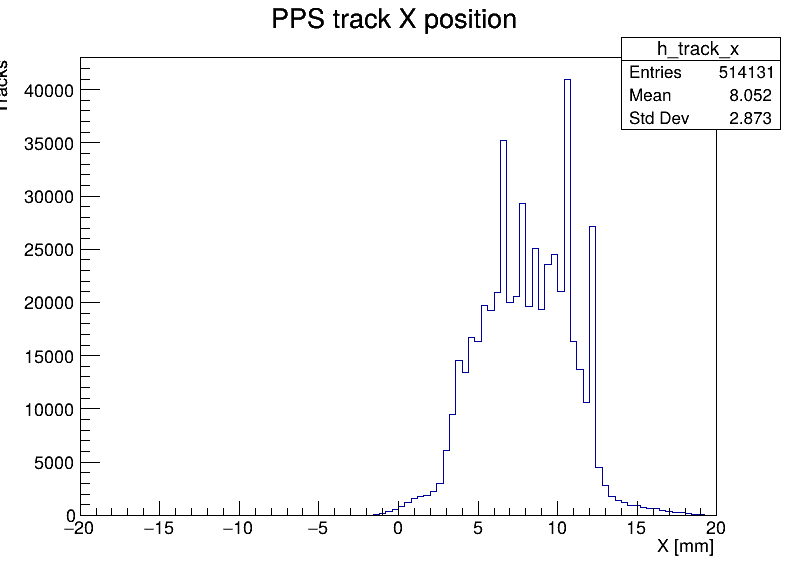

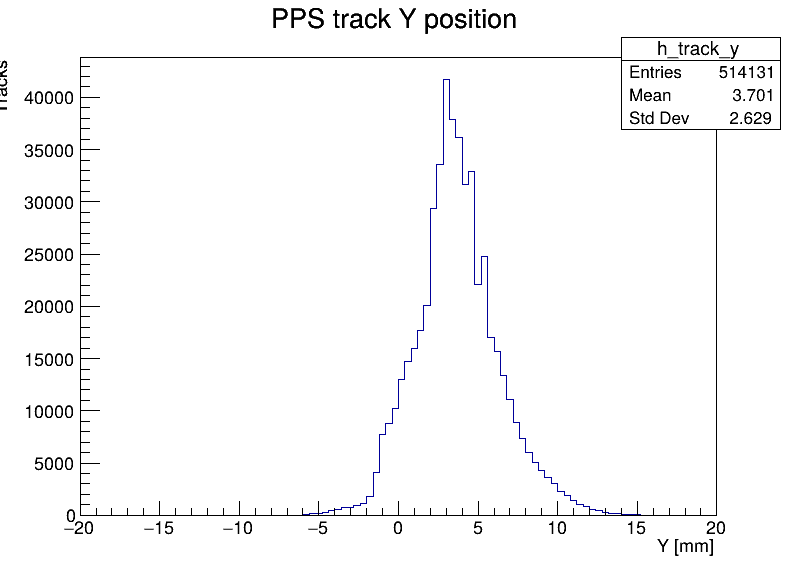

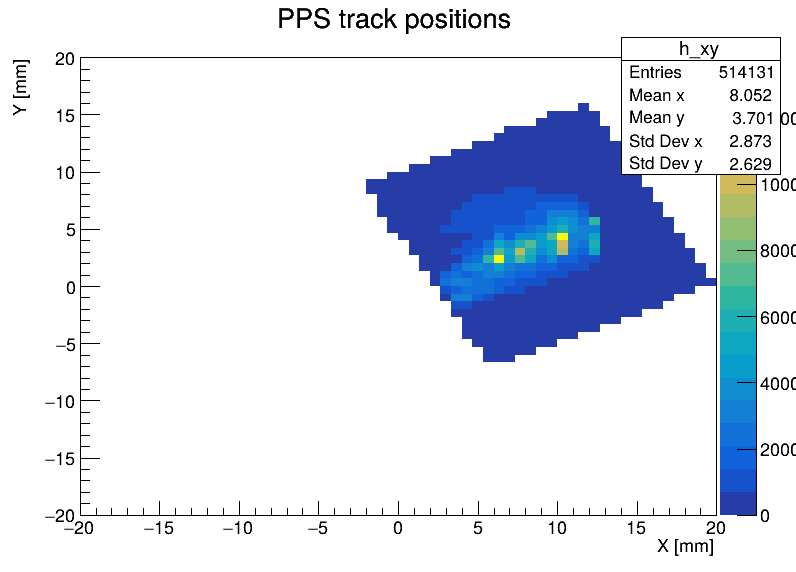

In [129]:
# Display the generated plots inline.
for name in histograms:
    png_path = os.path.join("data", f"pps_single_arm_{name}.png")
    if os.path.exists(png_path):
        display(Image(filename=png_path))


## 5. Applying calibration corrections (`apply_corrections.py`)

[`correctionlib`](https://github.com/cms-nanoAOD/correctionlib) is the
standard HEP tool for describing calibration/correction functions in a
portable JSON format. `apply_corrections_hybrid()`:

1. Reads a correction JSON file and its `metadata` block (which specifies
   `input_column` / `output_column` names, e.g. `PPSLocalTrack_x` →
   `PPSLocalTrack_x_corrected`)
2. Extracts the input column from the `RDataFrame` via `AsNumpy()`
3. Evaluates the correction per-track using the `correctionlib` Python API
4. Stores the results in a C++ global vector (via `ROOT.gInterpreter.Declare`)
   so they can be looked up efficiently from RDataFrame
5. Adds the corrected column back into the dataframe with `.Define()`

### Correction JSON format

```json
{
  "schema_version": 2,
  "corrections": [ ... ],
  "metadata": {
    "input_column": "PPSLocalTrack_x",
    "output_column": "PPSLocalTrack_x_corrected"
  }
}
```

### Example corrections shipped in `corrections-examples/`

| File | Correction type |
|---|---|
| `x_track_range_correction.json` | Position-dependent piecewise formulas (different linear correction per X range) |
| `per_track_direct_values.json` | Fixed per-track-index offsets |
| `per_track_binned_array.json` | Binned array lookup by track index |
| `per_event_per_track.json` | 2D correction, indexed by (event, track index) |


In [130]:
from apply_corrections import apply_corrections_hybrid

CORRECTION_FILE = "corrections-examples/x_track_range_correction.json"

df_corrected, input_column, output_column = apply_corrections_hybrid(
    df_baseline, CORRECTION_FILE
)
print(f"Input column:  {input_column}")
print(f"Output column: {output_column}")


=== Applying Corrections with correctionlib ===
Loading: corrections-examples/x_track_range_correction.json
✓ Loaded correction: track_position_correction
Extracting data from RDataFrame...
  Processed 5000/311565 events...
  Processed 10000/311565 events...
  Processed 15000/311565 events...
  Processed 20000/311565 events...
  Processed 25000/311565 events...
  Processed 30000/311565 events...
  Processed 35000/311565 events...
  Processed 40000/311565 events...
  Processed 45000/311565 events...
  Processed 50000/311565 events...
  Processed 55000/311565 events...
  Processed 60000/311565 events...
  Processed 65000/311565 events...
  Processed 70000/311565 events...
  Processed 75000/311565 events...
  Processed 80000/311565 events...
  Processed 85000/311565 events...
  Processed 90000/311565 events...
  Processed 95000/311565 events...
  Processed 100000/311565 events...
  Processed 105000/311565 events...
  Processed 110000/311565 events...
  Processed 115000/311565 events...
  

In [131]:
# Print df_corrected (single-arm, corrected) as a table: original vs corrected
# X values, event by event. RDataFrame's own.
df_corrected.Display(
    ["rdfentry_", input_column, output_column], 10
).Print()


+-----+-----------+-----------------+---------------------------+
| Row | rdfentry_ | PPSLocalTrack_x | PPSLocalTrack_x_corrected | 
+-----+-----------+-----------------+---------------------------+
| 0   | 0         | 5.660339        | 7.660339                  | 
|     |           | 5.168396        | 7.168396                  | 
|     |           | 8.532715        | 10.532715                 | 
|     |           | 10.095703       | 13.095703                 | 
|     |           | 5.713074        | 7.713074                  | 
|     |           | 8.304077        | 10.304077                 | 
|     |           | 9.999512        | 11.999512                 | 
+-----+-----------+-----------------+---------------------------+
| 2   | 2         | 4.411377        | 5.411377                  | 
|     |           | 2.793488        | 3.793488                  | 
|     |           | 10.916504       | 13.916504                 | 
+-----+-----------+-----------------+---------------------------+

In [132]:
CORRECTION_FILE = "corrections-examples/per_event_per_track.json"

df_corrected, input_column, output_column = apply_corrections_hybrid(
    df_single_arm, CORRECTION_FILE
)
print(f"Input column:  {input_column}")
print(f"Output column: {output_column}")

df_corrected.Display(
    ["rdfentry_", input_column, output_column], 10
).Print()

=== Applying Corrections with correctionlib ===
Loading: corrections-examples/per_event_per_track.json
✓ Loaded correction: x_per_event_and_track
Extracting data from RDataFrame...
  Processed 5000/34828 events...
  Processed 10000/34828 events...
  Processed 15000/34828 events...
  Processed 20000/34828 events...
  Processed 25000/34828 events...
  Processed 30000/34828 events...
✓ Correction column added

Input column:  PPSLocalTrack_x
Output column: PPSLocalTrack_x_corrected
+-----+-----------+-----------------+---------------------------+
| Row | rdfentry_ | PPSLocalTrack_x | PPSLocalTrack_x_corrected | 
+-----+-----------+-----------------+---------------------------+
| 7   | 7         | 6.280273        | 7.280273                  | 
+-----+-----------+-----------------+---------------------------+
| 12  | 12        | 2.994171        | 3.149171                  | 
|     |           | 4.538391        | 4.709391                  | 
+-----+-----------+-----------------+--------------

In [133]:
CORRECTION_FILE = "corrections-examples/per_track_binned_array.json"

df_corrected, input_column, output_column = apply_corrections_hybrid(
    df_single_arm, CORRECTION_FILE
)
print(f"Input column:  {input_column}")
print(f"Output column: {output_column}")

df_corrected.Display(
    ["rdfentry_", input_column, output_column], 10
).Print()

=== Applying Corrections with correctionlib ===
Loading: corrections-examples/per_track_binned_array.json
✓ Loaded correction: x_per_track_binned
Extracting data from RDataFrame...
  Processed 5000/34828 events...
  Processed 10000/34828 events...
  Processed 15000/34828 events...
  Processed 20000/34828 events...
  Processed 25000/34828 events...
  Processed 30000/34828 events...
✓ Correction column added

Input column:  PPSLocalTrack_x
Output column: PPSLocalTrack_x_corrected
+-----+-----------+-----------------+---------------------------+
| Row | rdfentry_ | PPSLocalTrack_x | PPSLocalTrack_x_corrected | 
+-----+-----------+-----------------+---------------------------+
| 7   | 7         | 6.280273        | 7.280273                  | 
+-----+-----------+-----------------+---------------------------+
| 12  | 12        | 2.994171        | 3.994171                  | 
|     |           | 4.538391        | 5.538391                  | 
+-----+-----------+-----------------+--------------

In [134]:
CORRECTION_FILE = "corrections-examples/per_track_direct_values.json"

df_corrected, input_column, output_column = apply_corrections_hybrid(
    df_single_arm, CORRECTION_FILE
)
print(f"Input column:  {input_column}")
print(f"Output column: {output_column}")

df_corrected.Display(
    ["rdfentry_", input_column, output_column], 10
).Print()

=== Applying Corrections with correctionlib ===
Loading: corrections-examples/per_track_direct_values.json
✓ Loaded correction: x_per_track_direct
Extracting data from RDataFrame...
  Processed 5000/34828 events...
  Processed 10000/34828 events...
  Processed 15000/34828 events...
  Processed 20000/34828 events...
  Processed 25000/34828 events...
  Processed 30000/34828 events...
✓ Correction column added

Input column:  PPSLocalTrack_x
Output column: PPSLocalTrack_x_corrected
+-----+-----------+-----------------+---------------------------+
| Row | rdfentry_ | PPSLocalTrack_x | PPSLocalTrack_x_corrected | 
+-----+-----------+-----------------+---------------------------+
| 7   | 7         | 6.280273        | 7.280273                  | 
+-----+-----------+-----------------+---------------------------+
| 12  | 12        | 2.994171        | 3.994171                  | 
|     |           | 4.538391        | 6.538391                  | 
+-----+-----------+-----------------+-------------

In [135]:
# Generate a correction JSON from a plain-text data table using
# corrections-examples/build_correction.py, then apply it like any other file.
sys.path.insert(0, "corrections-examples")
import build_correction

CORRECTION_FILE = build_correction.main()

df_corrected, input_column, output_column = apply_corrections_hybrid(
    df_single_arm, CORRECTION_FILE
)
print(f"Input column:  {input_column}")
print(f"Output column: {output_column}")

df_corrected.Display(
    ["rdfentry_", input_column, output_column], 10
).Print()

Wrote corrections-examples/generated_per_track_direct.json
Sanity check (re-evaluated from the written JSON):
  evaluate(0) = 1.0
  evaluate(1) = 2.0
  evaluate(2) = 3.0
  evaluate(3) = 4.0
  evaluate(4) = 5.0
  evaluate(5) = 6.0
  evaluate(11) = 0.0
=== Applying Corrections with correctionlib ===
Loading: corrections-examples/generated_per_track_direct.json
✓ Loaded correction: PPSLocalTrack_x_correction
Extracting data from RDataFrame...
  Processed 5000/34828 events...
  Processed 10000/34828 events...
  Processed 15000/34828 events...
  Processed 20000/34828 events...
  Processed 25000/34828 events...
  Processed 30000/34828 events...
✓ Correction column added

Input column:  PPSLocalTrack_x
Output column: PPSLocalTrack_x_corrected
+-----+-----------+-----------------+---------------------------+
| Row | rdfentry_ | PPSLocalTrack_x | PPSLocalTrack_x_corrected | 
+-----+-----------+-----------------+---------------------------+
| 7   | 7         | 6.280273        | 7.280273         

=== RDataFrame PPS Analysis ===
Analyzing file: examples/test.root

Total events in file: 346825
Events with PPS data: 311565

=== Applying Custom Filters ===
Applying filter 1: filter_rp23
  Events after filter: 218743

=== Filter Results ===
Events after all filters: 218743

=== Applying Corrections with correctionlib ===
Loading: corrections-examples/x_track_range_correction.json
✓ Loaded correction: track_position_correction
Extracting data from RDataFrame...
  Processed 5000/218743 events...
  Processed 10000/218743 events...
  Processed 15000/218743 events...
  Processed 20000/218743 events...
  Processed 25000/218743 events...
  Processed 30000/218743 events...
  Processed 35000/218743 events...
  Processed 40000/218743 events...
  Processed 45000/218743 events...
  Processed 50000/218743 events...
  Processed 55000/218743 events...
  Processed 60000/218743 events...
  Processed 65000/218743 events...
  Processed 70000/218743 events...
  Processed 75000/218743 events...
  Proces

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_pps_rp23_original_track_x


Saved: data/pps_rp23_original_track_x.png

=== Histogram Creation Complete ===
=== Creating Histograms ===
Creating histogram for: PPSLocalTrack_x_corrected
Created 1 histogram(s)

=== Creating Plots ===
Saved: data/pps_rp23_corrected_track_x.png

=== Histogram Creation Complete ===


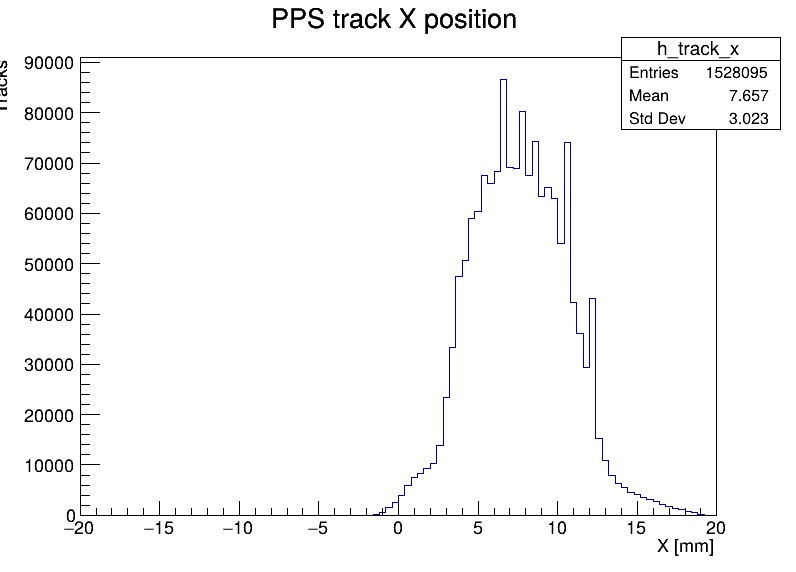

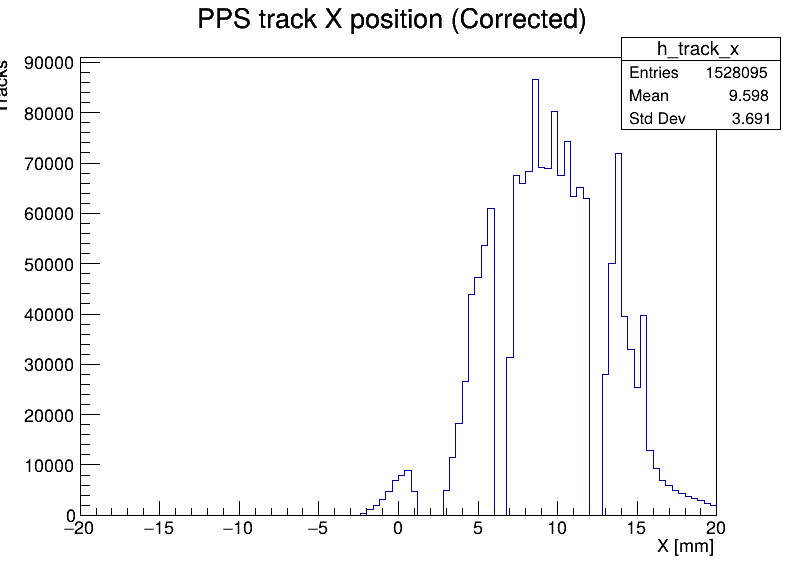

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_pps_rp23_corrected_track_x


In [136]:
def filter_rp23(df): return filter_detector_specific_events(df, 23)
df_d = rdata_analysis(FILE_PATH, [filter_rp23])

df_d_corrected, in_col, out_col = apply_corrections_hybrid(
    df_d, "corrections-examples/x_track_range_correction.json"
)

create_histograms_and_plots(
    df_d_corrected, [PPSHistogramType.PPS_LOCAL_TRACK_X],
    output_prefix="pps_rp23_original", corrections=False, save_root=False,
)
create_histograms_and_plots(
    df_d_corrected, [PPSHistogramType.PPS_LOCAL_TRACK_X],
    output_prefix="pps_rp23_corrected", corrections=True, save_root=False,
)

display(Image(filename="data/pps_rp23_original_track_x.png"))
display(Image(filename="data/pps_rp23_corrected_track_x.png"))


## 6. Diamond detector proton efficiency

Computes proton reconstruction efficiency for both diamond timing pot types:
"box" pots (RP 22 arm 45, RP 122 arm 56, 3 sub-regions) and "cyl" pots
(RP 16 arm 45, RP 116 arm 56, 4 sub-regions).

Pipeline (shared by both pot types, selected via a `pot_type` ("box"/"cyl") argument):
1. Select tracks in a specific RP with the existing universal filter
   `filter_detector_specific_events(df, rp_id)`.
2. Split that RP's rectangular acceptance into N equal sensor-width
   sub-regions (3 for box, 4 for cyl), defined in `diamond_geometry.py`'s
   `POT_CONFIG` as a hardcoded, **rotated** `center +/- (sensor_dimension / 2)`
   box per pot type/arm. The tilt angle is the real alignment value from
   `diamond_alignment_coords_2025.json` (`boxAngle`/`cylAngle` = 28.5 deg for
   both pot types and both arms). The centers are empirical — the hit band's
   centroid per RP, plus a small leftward nudge in x read off the all-pot maps.
   The alignment file's absolute X/Y can't be used instead
   (`PPSLocalTrack_x/y` here aren't alignment-corrected), and neither reading of
   its per-run shift table reproduces this sample (run 396727): summing the
   increments puts the pots at x = 48–69 mm, several times past the data, while
   treating the last entry as cumulative still overshoots the cloud by +3.3 to
   +6.9 mm to the right.
3. `build_diamond_efficiency_json()` (in `corrections-examples/build_correction.py`)
   writes a **correctionlib JSON** mapping `region_idx` to the corresponding
   `efficiency.json` `"box"`/`"cyl"` value.
4. `apply_diamond_efficiency_jit()` (in `apply_corrections.py`) evaluates the
   correctionlib JSON once per region at setup, bakes those values into a
   JIT-compiled C++ kernel (generated from `POT_CONFIG` by
   `diamond_geometry.get_cpp_source()`), and adds a `PPSLocalTrack_efficiency`
   column with a single `Define()`. The kernel assigns each track's region via
   the same rotated-frame range test as `assign_region()`.
5. A 2D X/Y efficiency map is drawn with the rotated regions and their
   efficiency values overlaid, matching the reference plot.

> In-region coverage is 99.8% / 99.7% for box and 97.5% / 96.0% for cyl. The

> cyl band is 18 mm long along its axis while the hit cloud spans only ~10.4 mm,
> so its trailing region stays essentially empty.

In [139]:
import importlib
import json

sys.path.insert(0, "corrections-examples")

import analyze_proton_events
import apply_corrections
import diamond_geometry

from build_correction import build_diamond_efficiency_json

# Pick up geometry/kernel/plotting edits without restarting the kernel. Reload order follows
# the dependency order, and names pulled in by `from ... import` earlier have to be re-bound
# afterwards -- reload() rebuilds the module, it does not touch existing bindings.
importlib.reload(diamond_geometry)
importlib.reload(apply_corrections)
importlib.reload(analyze_proton_events)
from analyze_proton_events import plot_all_pots_with_regions, plot_diamond_efficiency_maps
from apply_corrections import apply_diamond_efficiency_jit

EFFICIENCY_FILE = "efficiency.json"

with open(EFFICIENCY_FILE) as f:
    efficiency_data = json.load(f)

# Whole file corresponds to a single run; read it from the 'run' branch.
try:
    run_values = ROOT.RDataFrame("Events", FILE_PATH).Range(1).AsNumpy(["run"])["run"]
    RUN_NUMBER = int(run_values[0])
    if str(RUN_NUMBER) not in efficiency_data:
        print(f"Warning: run {RUN_NUMBER} not in {EFFICIENCY_FILE}, falling back to its only key")
        RUN_NUMBER = int(next(iter(efficiency_data)))
except Exception as e:
    print(f"Warning: could not read 'run' branch ({e}), falling back to {EFFICIENCY_FILE}'s only key")
    RUN_NUMBER = int(next(iter(efficiency_data)))

print(f"Using run number: {RUN_NUMBER}")


Using run number: 396733


In [140]:
ARM_RP_IDS = {"45": 22, "56": 122}
diamond_dfs = {}

for arm_key, rp_id in ARM_RP_IDS.items():
    print(f"--- Arm {arm_key} (RP {rp_id}) ---")
    correction_json = build_diamond_efficiency_json(
        EFFICIENCY_FILE, arm_key, RUN_NUMBER,
        f"corrections-examples/diamond_efficiency_arm{arm_key}.json",
    )
    df_rp = filter_detector_specific_events(df_baseline, rp_id)
    df_eff = apply_diamond_efficiency_jit(df_rp, rp_id, arm_key, correction_json)
    # Restrict to this RP's own tracks -- the raw arrays are jagged across all RPs in the event.
    df_eff = df_eff.Define("PPSLocalTrack_x_rp", f"PPSLocalTrack_x[PPSLocalTrack_decRPId == {rp_id}]")
    df_eff = df_eff.Define("PPSLocalTrack_y_rp", f"PPSLocalTrack_y[PPSLocalTrack_decRPId == {rp_id}]")
    df_eff = df_eff.Define(
        "PPSLocalTrack_efficiency_rp", f"PPSLocalTrack_efficiency[PPSLocalTrack_decRPId == {rp_id}]"
    )
    diamond_dfs[arm_key] = df_eff
    df_eff.Display(
        ["rdfentry_", "PPSLocalTrack_x_rp", "PPSLocalTrack_y_rp", "PPSLocalTrack_efficiency_rp"], 10
    ).Print()


--- Arm 45 (RP 22) ---
Wrote corrections-examples/diamond_efficiency_arm45.json
=== Applying Diamond Box Efficiency ===
Loaded correction: diamond_box_efficiency_arm45
Efficiency column added

+-----+-----------+--------------------+--------------------+-----------------------------+
| Row | rdfentry_ | PPSLocalTrack_x_rp | PPSLocalTrack_y_rp | PPSLocalTrack_efficiency_rp | 
+-----+-----------+--------------------+--------------------+-----------------------------+
| 3   | 3         | 6.652344           | 2.084961           | 0.931259                    | 
+-----+-----------+--------------------+--------------------+-----------------------------+
| 6   | 6         | 8.651855           | 4.526367           | 0.966471                    | 
+-----+-----------+--------------------+--------------------+-----------------------------+
| 9   | 9         | 9.605835           | 4.099609           | 0.966471                    | 
+-----+-----------+--------------------+--------------------+------

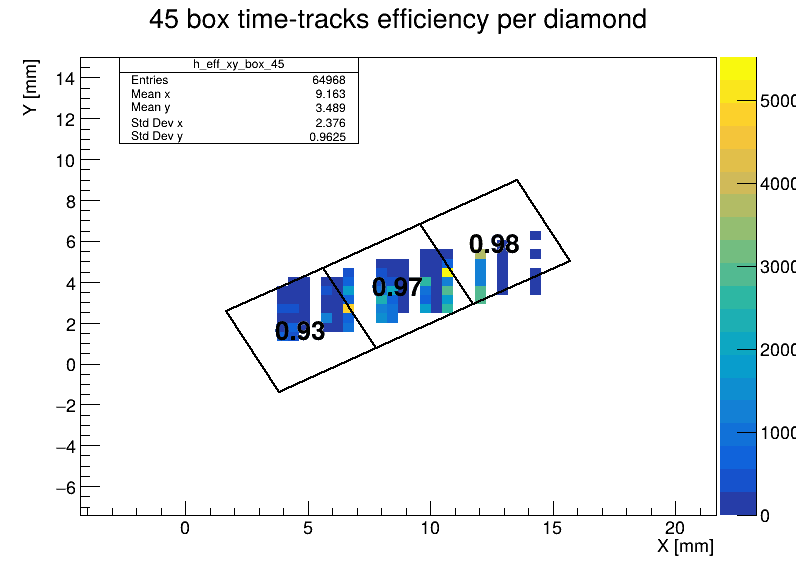

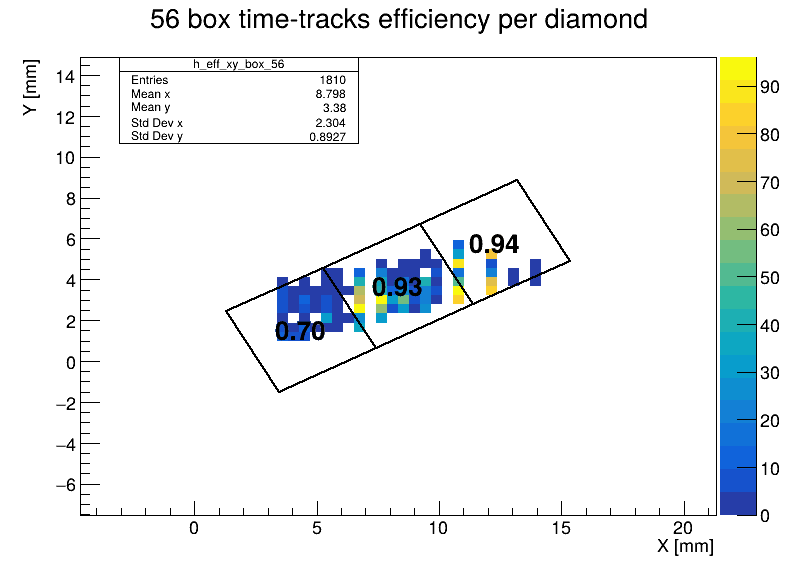

In [141]:
output_pngs = plot_diamond_efficiency_maps(diamond_dfs, efficiency_data, RUN_NUMBER, ARM_RP_IDS, pot_type="box")

for arm_key, output_png in output_pngs.items():
    display(Image(filename=output_png))


### Comparison: all-pot tracks vs. single-RP tracks

The maps above are restricted to one diamond RP's own tracks
(`PPSLocalTrack_x_rp`/`PPSLocalTrack_y_rp`), which is why their granularity
looks coarser -- that's the real channel structure of a single sensor.
For comparison, the cell below plots the raw `PPSLocalTrack_x`/`PPSLocalTrack_y`
branches (all tracks, all RPs) for the same event selection, matching how the
earlier `pps_single_arm_xy` / `h_xy` plots were made.


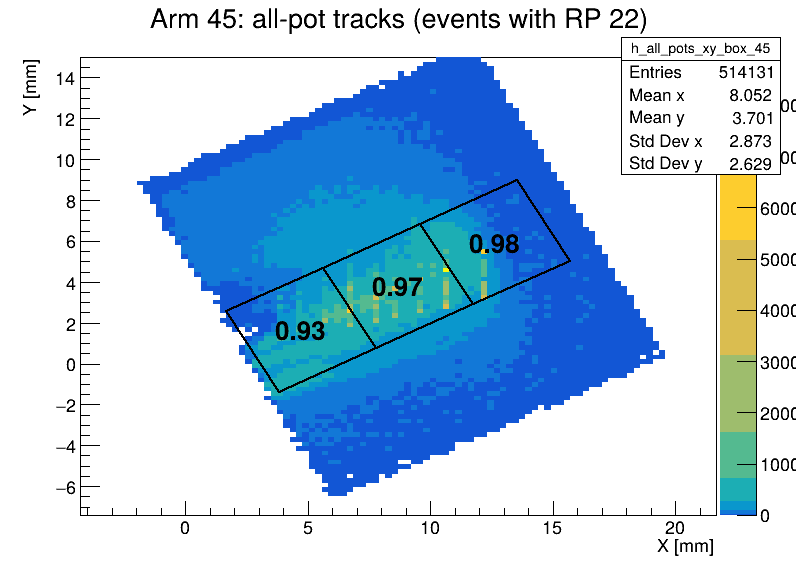

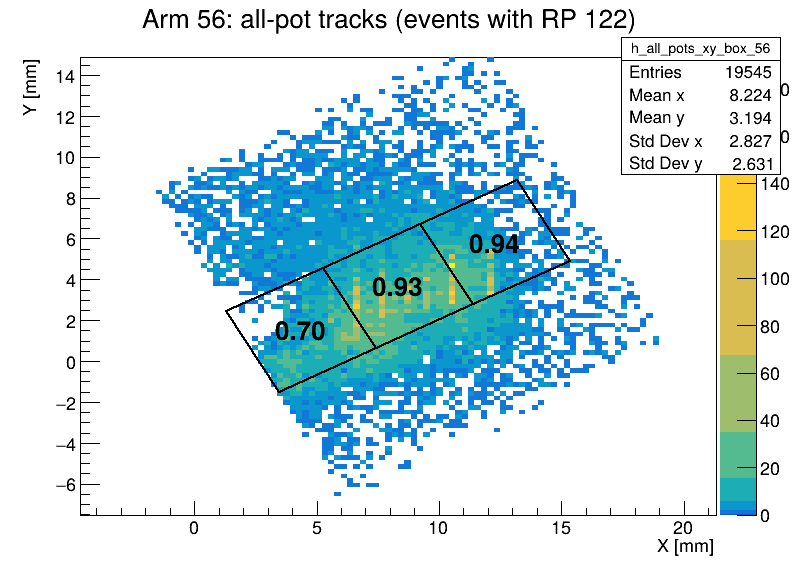

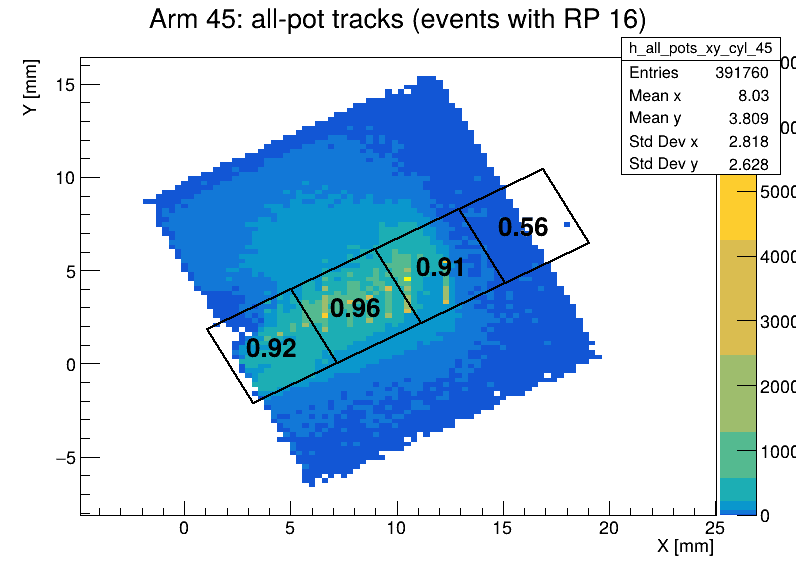

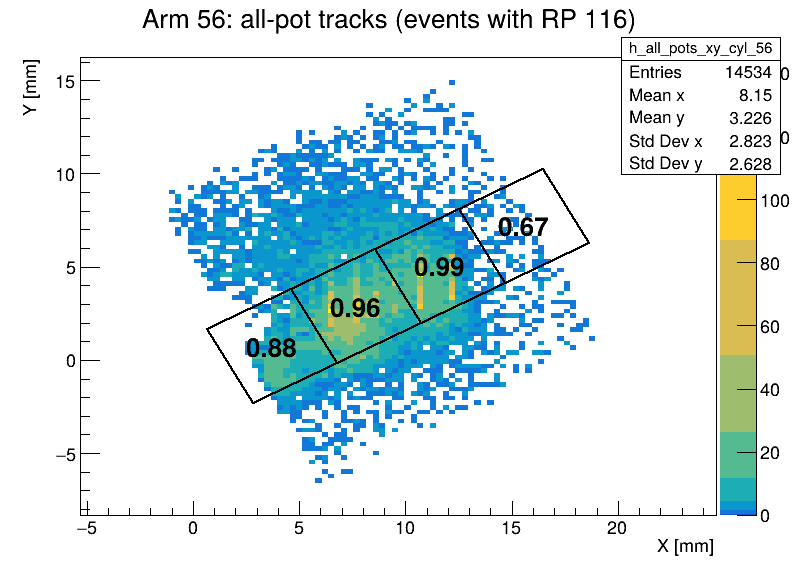

In [142]:
from analyze_proton_events import plot_all_pots_with_regions

output_pngs_all_pots_box = plot_all_pots_with_regions(df_baseline, ARM_RP_IDS, efficiency_data, RUN_NUMBER, pot_type="box")
for arm_key, output_png in output_pngs_all_pots_box.items():
    display(Image(filename=output_png))

output_pngs_all_pots_cyl = plot_all_pots_with_regions(df_baseline, ARM_RP_IDS_CYL, efficiency_data, RUN_NUMBER, pot_type="cyl")
for arm_key, output_png in output_pngs_all_pots_cyl.items():
    display(Image(filename=output_png))



In [143]:
ARM_RP_IDS_CYL = {"45": 16, "56": 116}
diamond_dfs_cyl = {}

for arm_key, rp_id in ARM_RP_IDS_CYL.items():
    print(f"--- Arm {arm_key} (RP {rp_id}) ---")
    correction_json = build_diamond_efficiency_json(
        EFFICIENCY_FILE, arm_key, RUN_NUMBER,
        f"corrections-examples/diamond_efficiency_cyl_arm{arm_key}.json",
        pot_type="cyl",
    )
    df_rp = filter_detector_specific_events(df_baseline, rp_id)
    df_eff = apply_diamond_efficiency_jit(df_rp, rp_id, arm_key, correction_json, pot_type="cyl")
    # Restrict to this RP's own tracks -- the raw arrays are jagged across all RPs in the event.
    df_eff = df_eff.Define("PPSLocalTrack_x_rp", f"PPSLocalTrack_x[PPSLocalTrack_decRPId == {rp_id}]")
    df_eff = df_eff.Define("PPSLocalTrack_y_rp", f"PPSLocalTrack_y[PPSLocalTrack_decRPId == {rp_id}]")
    df_eff = df_eff.Define(
        "PPSLocalTrack_efficiency_rp", f"PPSLocalTrack_efficiency[PPSLocalTrack_decRPId == {rp_id}]"
    )
    diamond_dfs_cyl[arm_key] = df_eff
    df_eff.Display(
        ["rdfentry_", "PPSLocalTrack_x_rp", "PPSLocalTrack_y_rp", "PPSLocalTrack_efficiency_rp"], 10
    ).Print()


--- Arm 45 (RP 16) ---
Wrote corrections-examples/diamond_efficiency_cyl_arm45.json
=== Applying Diamond Cyl Efficiency ===
Loaded correction: diamond_cyl_efficiency_arm45
Efficiency column added

+-----+-----------+--------------------+--------------------+-----------------------------+
| Row | rdfentry_ | PPSLocalTrack_x_rp | PPSLocalTrack_y_rp | PPSLocalTrack_efficiency_rp | 
+-----+-----------+--------------------+--------------------+-----------------------------+
| 3   | 3         | 6.652344           | 2.084961           | 0.964333                    | 
+-----+-----------+--------------------+--------------------+-----------------------------+
| 17  | 17        | 6.651550           | 3.618408           | 0.964333                    | 
+-----+-----------+--------------------+--------------------+-----------------------------+
| 28  | 28        | 7.791992           | 2.158691           | 0.964333                    | 
+-----+-----------+--------------------+--------------------+--

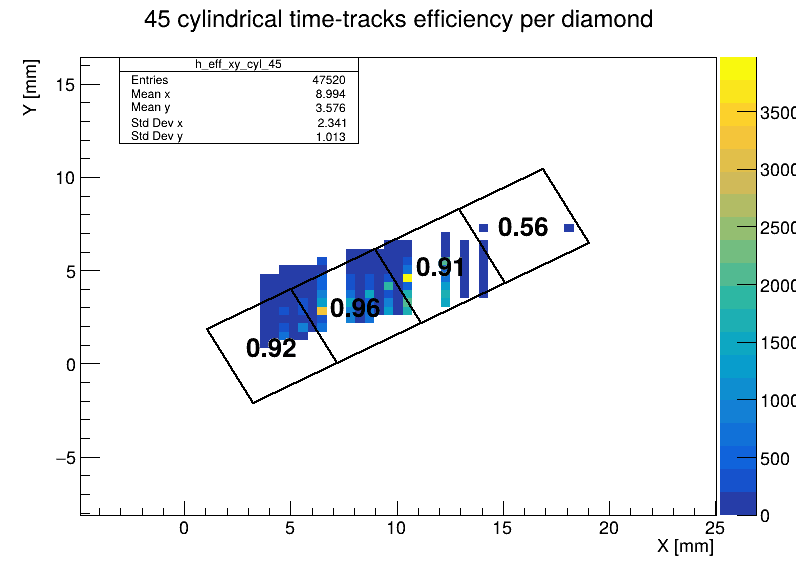

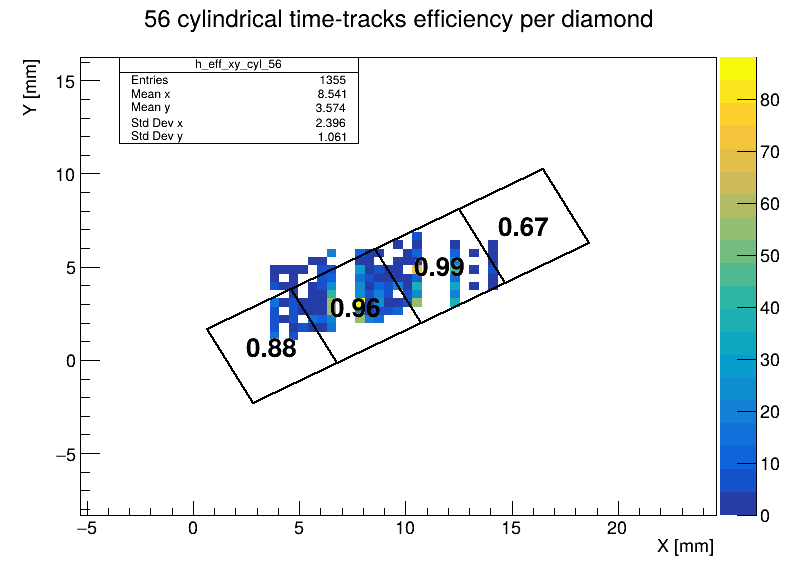

In [115]:
output_pngs_cyl = plot_diamond_efficiency_maps(
    diamond_dfs_cyl, efficiency_data, RUN_NUMBER, ARM_RP_IDS_CYL, pot_type="cyl"
)

for arm_key, output_png in output_pngs_cyl.items():
    display(Image(filename=output_png))
